In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from collections import Counter

In [2]:
df = pd.read_csv("traffic.csv")

df.head()

,event,date,country,city,artist,album,track,isrc,linkid
0,click,2021-08-21,Saudi Arabia,Jeddah,Tesher,Jalebi Baby,Jalebi Baby,QZNWQ2070741,2d896d31-97b6-4869-967b-1c5fb9cd4bb8
1,click,2021-08-21,Saudi Arabia,Jeddah,Tesher,Jalebi Baby,Jalebi Baby,QZNWQ2070741,2d896d31-97b6-4869-967b-1c5fb9cd4bb8
2,click,2021-08-21,India,Ludhiana,Reyanna Maria,So Pretty,So Pretty,USUM72100871,23199824-9cf5-4b98-942a-34965c3b0cc2
3,click,2021-08-21,France,Unknown,"Simone & Simaria, Sebastian Yatra",No Llores Más,No Llores Más,BRUM72003904,35573248-4e49-47c7-af80-08a960fa74cd
4,click,2021-08-21,Maldives,Malé,Tesher,Jalebi Baby,Jalebi Baby,QZNWQ2070741,2d896d31-97b6-4869-967b-1c5fb9cd4bb8


In [6]:
import pandas as pd

df = pd.read_csv("traffic.csv")

print(df.columns)

Index(['event', 'date', 'country', 'city', 'artist', 'album', 'track', 'isrc',
       'linkid'],
      dtype='str')


In [9]:
df.drop_duplicates(inplace=True)

df['date'] = pd.to_datetime(df['date'])

df.fillna('Unknown', inplace=True)

print(df.isnull().sum())

event      0
date       0
country    0
city       0
artist     0
album      0
track      0
isrc       0
linkid     0
dtype: int64


In [10]:
print("Total Records:", len(df))

Total Records: 122567


In [11]:
event_counts = df['event'].value_counts()

print(event_counts)

event
pageview    73360
click       32499
preview     16708
Name: count, dtype: int64


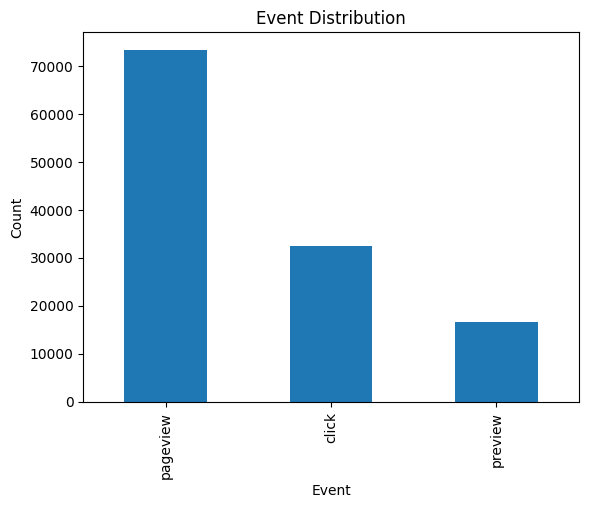

In [12]:
import matplotlib.pyplot as plt

event_counts.plot(kind='bar')

plt.title("Event Distribution")
plt.xlabel("Event")
plt.ylabel("Count")
plt.show()

In [13]:
top_countries = df['country'].value_counts().head(10)

print(top_countries)

country
United States     28664
India             18689
France            10565
Saudi Arabia       7682
United Kingdom     5095
Germany            4017
Canada             2784
Pakistan           2633
Iraq               2444
Turkey             2399
Name: count, dtype: int64


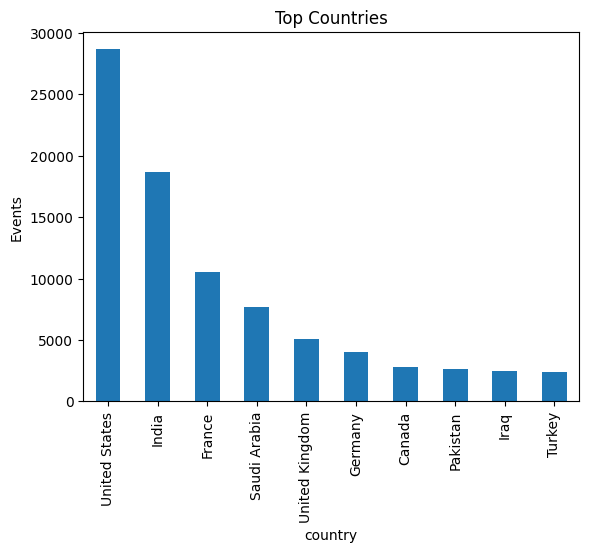

In [14]:
top_countries.plot(kind='bar')

plt.title("Top Countries")
plt.ylabel("Events")

plt.show()

In [15]:
top_cities = df['city'].value_counts().head(10)

print(top_cities)

city
Unknown        8802
Jeddah         2497
Riyadh         2232
Hyderabad      1088
Dammam         1002
Delhi           884
Jaipur          849
Lucknow         837
Kuwait City     816
Ahmedabad       808
Name: count, dtype: int64


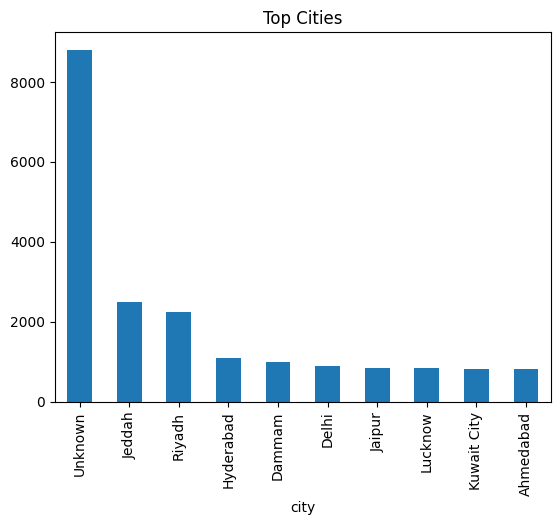

In [16]:
top_cities.plot(kind='bar')

plt.title("Top Cities")

plt.show()

In [17]:
top_artists = df['artist'].value_counts().head(10)

print(top_artists)

artist
Tesher                                                          8288
Anne-Marie                                                      4029
Tundra Beats                                                    3951
Roddy Ricch                                                     3107
Olivia Rodrigo                                                  3037
Surf Mesa, Emilee                                               2956
DMNDS, Strange Fruits Music, Fallen Roses, Lujavo, Nito-Onna    2865
Reyanna Maria                                                   2675
PinkPantheress                                                  2446
50 Cent, Olivia                                                 2390
Name: count, dtype: int64


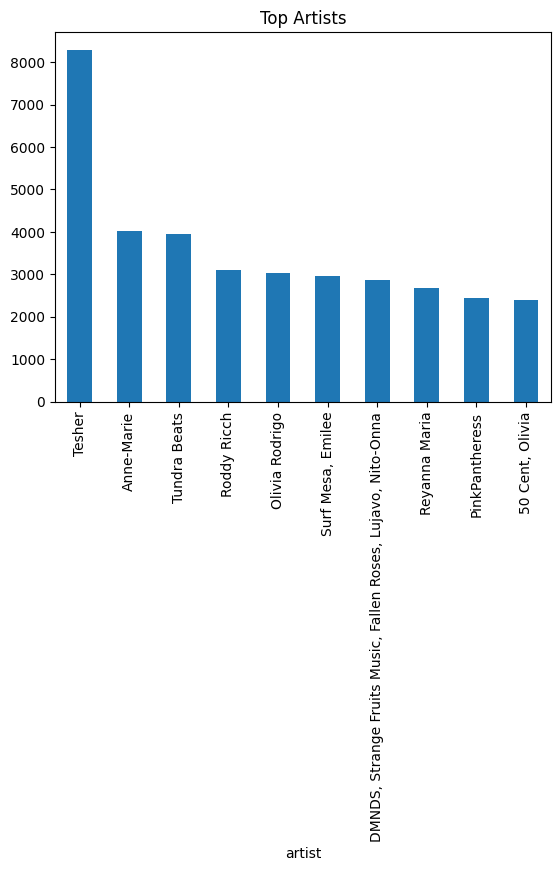

In [18]:
top_artists.plot(kind='bar')

plt.title("Top Artists")

plt.show()

In [19]:
top_tracks = df['track'].value_counts().head(10)

print(top_tracks)

track
Jalebi Baby                              8288
Beautiful                                4037
Beautiful Day                            3951
Late At Night                            3059
ily (i love you baby) (feat. Emilee)     2956
Calabria (feat. Lujavo & Nito-Onna)      2865
So Pretty                                2830
Candy Shop                               2397
Summer of Love (Shawn Mendes & Tainy)    2108
Build a Bitch                            2072
Name: count, dtype: int64


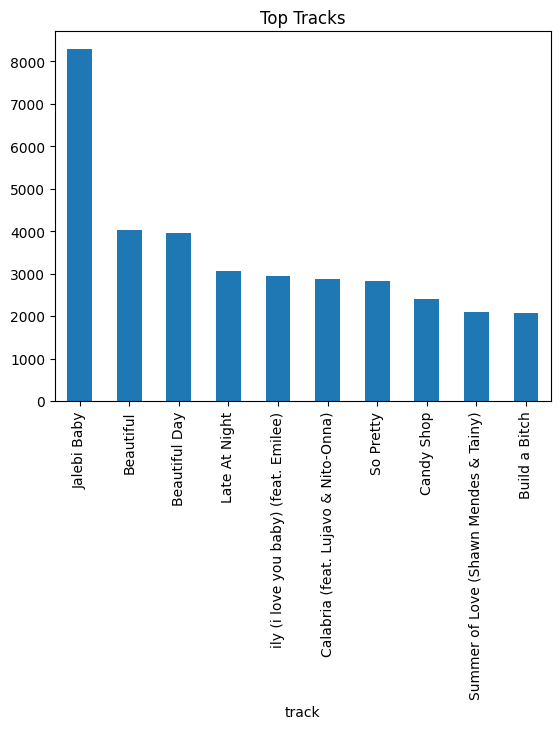

In [20]:
top_tracks.plot(kind='bar')

plt.title("Top Tracks")

plt.show()

C:\Users\VICTUS\AppData\Local\Programs\Python\Python314\Lib\site-packages\pandas\plotting\_matplotlib\core.py:1613: UserWarning: Attempting to set identical low and high xlims makes transformation singular; automatically expanding.
  ax.set_xlim(left, right)


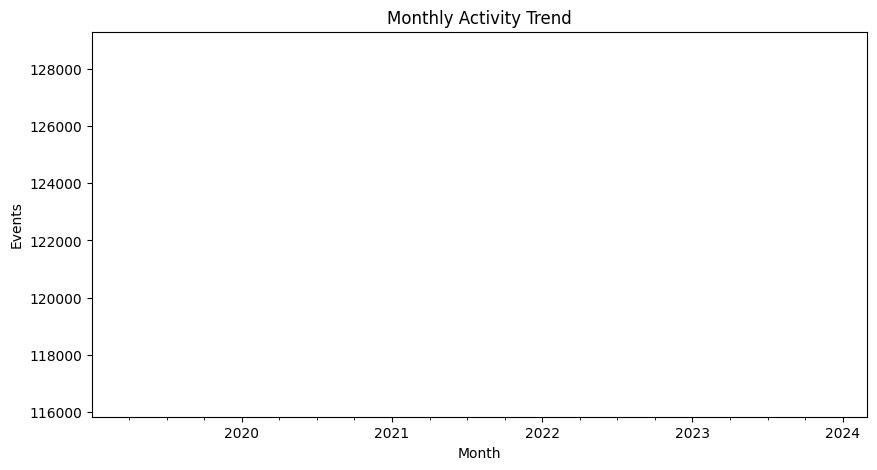

In [21]:
df['month'] = df['date'].dt.to_period('M')

monthly_activity = df.groupby('month').size()

monthly_activity.plot(figsize=(10,5))

plt.title("Monthly Activity Trend")
plt.xlabel("Month")
plt.ylabel("Events")

plt.show()

In [22]:
top_albums = df['album'].value_counts().head(10)

print(top_albums)

album
Jalebi Baby                             8288
Beautiful                               4028
Beautiful Day                           3950
Late At Night                           3059
ily (i love you baby) (feat. Emilee)    2956
SOUR                                    2878
The Massacre                            2870
Calabria (feat. Lujavo & Nito-Onna)     2865
So Pretty                               2830
Summer Of Love                          2108
Name: count, dtype: int64


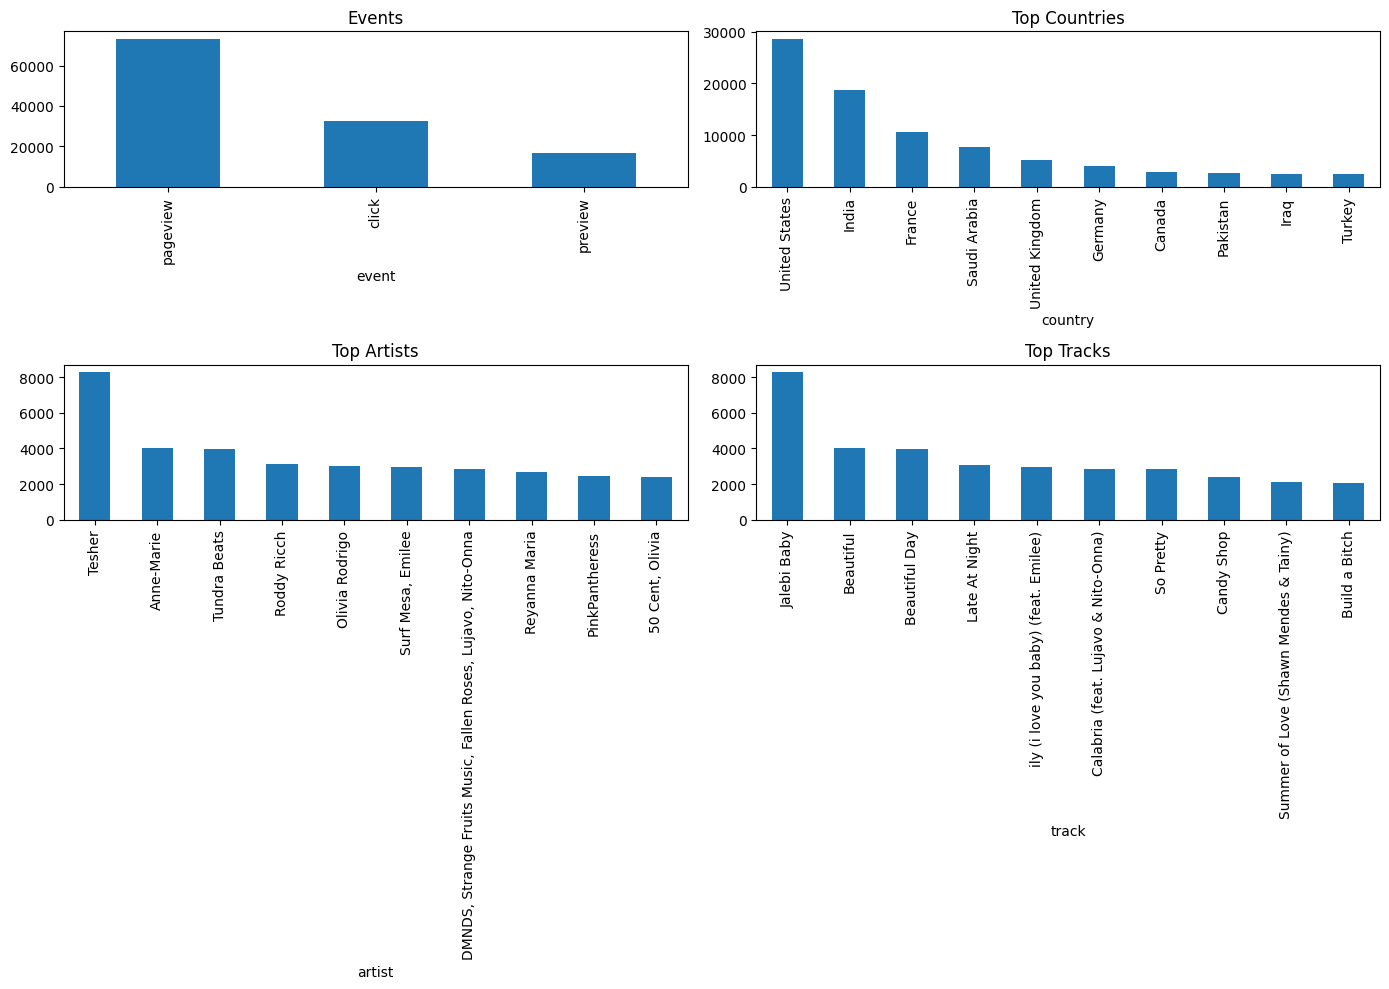

In [23]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(2,2, figsize=(14,10))

df['event'].value_counts().plot(kind='bar', ax=ax[0,0])
ax[0,0].set_title("Events")

df['country'].value_counts().head(10).plot(kind='bar', ax=ax[0,1])
ax[0,1].set_title("Top Countries")

df['artist'].value_counts().head(10).plot(kind='bar', ax=ax[1,0])
ax[1,0].set_title("Top Artists")

df['track'].value_counts().head(10).plot(kind='bar', ax=ax[1,1])
ax[1,1].set_title("Top Tracks")

plt.tight_layout()
plt.show()